Environment: ciao-4.15

In [1]:
import glob
import os, sys

import numpy as np
import astropy.units as u
import astropy.constants as c
from astropy.table import Table, vstack, hstack, join
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Georgia']
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.linewidth'] = 1

In [2]:
def rolling_median(y, window):
    median = np.zeros(len(y))
    for i in range(len(y)):
        median[i] = np.nanmedian(y[np.max([i-window, 0]) : np.min([i+window, len(y)])])
    return median

# Analysis Overview
- First we do the initial processing using the SAS processes `emproc`, `epproc`, and `rgsproc`. This is done in `0101440801/Initial Processing.ipynb` and `0671960101/Initial Processing.ipynb` for the 2002 and 2012 data, respectively.
- Then we extract the spectra. This is done in `0101440801/Extraction.ipynb` for the 2002 data and in `0671960101/Extraction.ipynb` for the 2012 data. Flare and Quiescent definitions are shown in plot below. The 2002 flare definitions were tested to in `0101440801/Extraction - Flare.ipynb`.
- For all fitting, we group elemental abundances into low-FIP, mid-FIP, and high-FIP groups, and let all three groups vary. The low-FIP group is Fe, Al, Ca, Mg, Ni, Si. The mid-FIP group is O, C, N, S. The high-FIP group is Ne.
- For the first fits, we test which model to use, in `model_testing.ipynb`. We test a total of seven different models, three of which are more complex than can be supported by the data, and are tested only for completeness. The other four are included in the paper. Model testing used only the quiescent data.
- Using Flare and Quiescent data for both 2002 and 2012 data
- 

# Plotting Data

## 2012 Lightcurves

In [3]:
# Plot all SU Aur LCs, 0671960101
tc = 60*60*24  # convert to days
xmm = 50814.0  # XMM Newton Reference time 

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/SU_Aur/0671960101/SUAur_combined_lc.lc')
lc = Table(hdul[1].data)
x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x = x/tc + xmm
y = np.sum(lc['RATE'], 1)
y_err = np.sum(lc['ERROR'][:,:2], 1)
x_obs_start = x[0]
x_end = x[-1]

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/SU_Aur/0671960101/SUAur_combined_lc_soft.lc')
lc_soft = Table(hdul[1].data)
x_soft = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x_soft = x_soft/tc + xmm
y_soft = np.sum(lc_soft['RATE'], 1)
y_err_soft = np.sum(lc_soft['ERROR'][:,:2], 1)

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/SU_Aur/0671960101/SUAur_combined_lc_hard.lc')
lc_hard = Table(hdul[1].data)
x_hard = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x_hard = x_hard/tc + xmm
y_hard = np.sum(lc_hard['RATE'], 1)
y_err_hard = np.sum(lc_hard['ERROR'][:,:2], 1)

/Users/woodml/anaconda3/envs/ciao-4.15/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [4]:
# Load OM
om_lc = Table.read('/Users/woodml/Observing/XMM-Newton/SU_Aur/0671960101/OM_0671960101_LC.lc', format='ascii', delimiter=',', fast_reader=False, guess=False)

In [5]:
print(445818000/tc + xmm)

55973.930555555555


In [6]:
print(x[0], x[-1])

55972.88385416666 55974.05515046296


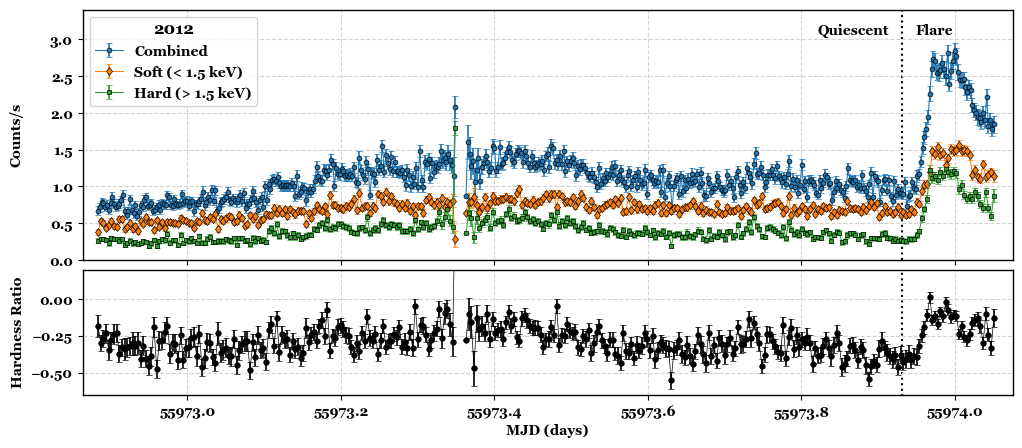

In [9]:
# Plot all SU Aur LCs, 0101440801, 200s bins
ratio_err = 2/(y_hard+y_soft)**2 * np.sqrt(y_soft**2*y_err_hard**2 + y_hard**2*y_err_soft**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.05, 'height_ratios':[2,1]}, figsize=(12,5))
ax[0].errorbar(x, y, yerr=y_err, lw=0.75, ms=7, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(x_soft, y_soft, yerr=y_err_soft, lw=0.75, marker='d', ms=4.4, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft (< 1.5 keV)')
ax[0].errorbar(x_hard, y_hard, yerr=y_err_hard, lw=0.75, marker='s', ms=3.5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard (> 1.5 keV)')
ax[0].vlines([445818000/tc + xmm], 0, 3.5, 'k', ':', zorder=1)
ax[0].text(0.895, 0.9, 'Flare', transform=ax[0].transAxes)
ax[0].text(0.79, 0.9, 'Quiescent', transform=ax[0].transAxes)
ax[0].xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].set_xlim(x[0]-0.02, x[-1]+0.02)
ax[0].set_ylim(0, 3.4)
ax[0].set_ylabel('Counts/s', labelpad=18)
ax[0].legend(title='2012', title_fontsize=12)

ax[1].errorbar(x_soft, (y_hard - y_soft)/(y_hard + y_soft), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].vlines([445818000/tc + xmm], -1, 1, 'k', ':', zorder=1)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].set_ylim(-0.65, 0.2)
ax[1].set_xlabel('MJD (days)')
ax[1].set_ylabel('Hardness Ratio')
plt.savefig('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/figure_2012_lc.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

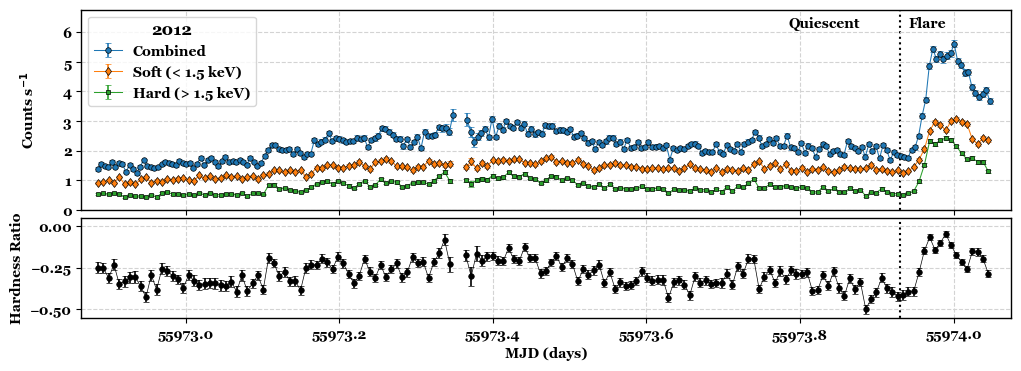

In [10]:
# Plot all SU Aur LCs, 0101440801, 400s bins
x3 = np.array([np.median(x[i:i+2]) for i in range(0,len(x),2)])
y3 = np.array([np.sum(y[i:i+2]) for i in range(0,len(x),2)])
y_err3 = np.array([np.sum(y_err[i:i+2])/2 for i in range(0,len(x),2)])

xs3 = np.array([np.median(x_soft[i:i+2]) for i in range(0,len(x_soft), 2)])
ys3 = np.array([np.sum(y_soft[i:i+2]) for i in range(0,len(x_soft), 2)])
ys_err3 = np.array([np.sum(y_err_soft[i:i+2])/2 for i in range(0,len(x_soft), 2)])

xh3 = np.array([np.median(x_hard[i:i+2]) for i in range(0,len(x_hard),2)])
yh3 = np.array([np.sum(y_hard[i:i+2]) for i in range(0,len(x_hard),2)])
yh_err3 = np.array([np.sum(y_err_hard[i:i+2])/2 for i in range(0,len(x_hard),2)])

# = 2/(x_1+x_2 )^2  np.sqrt(x_2^2 σ_(x_1)^2+ x_1^2 σ_(x_2)^2 )
ratio_err = 2/(yh3+ys3)**2 * np.sqrt(ys3**2*yh_err3**2 + yh3**2*ys_err3**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.05, 'height_ratios':[2,1]}, figsize=(12,4))
ax[0].errorbar(x3, y3, yerr=y_err3, lw=0.75, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(xs3, ys3, yerr=ys_err3, lw=0.75, marker='d', ms=4.4, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft (< 1.5 keV)')
ax[0].errorbar(xh3, yh3, yerr=yh_err3, lw=0.75, marker='s', ms=3.5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard (> 1.5 keV)')
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].vlines([445818000/tc + xmm], 0, 7, 'k', ':', zorder=1)
ax[0].text(0.89, 0.91, 'Flare', transform=ax[0].transAxes)
ax[0].text(0.76, 0.91, 'Quiescent', transform=ax[0].transAxes)
ax[0].xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax[0].set_xlim(x[0]-0.02, x[-1]+0.02)
ax[0].set_ylim(0, 6.75)
ax[0].set_ylabel('Counts s$^{-1}$', labelpad=18)
ax[0].legend(title='2012', title_fontsize=12)

ax[1].errorbar(xs3, (yh3-ys3)/(yh3+ys3), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].vlines([445818000/tc + xmm], -0.75, 0.25, 'k', ':', zorder=1)
ax[1].set_ylim(-0.55, 0.05)
ax[1].set_xlabel('MJD (days)')
ax[1].set_ylabel('Hardness Ratio')
plt.savefig('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/figure_2012_lc.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Flare Morphology

Rise time:  55973.9509837963
Rise phase:  0.444 hours
Plateau:  0.889 hours
Decay: > 1.167 hours


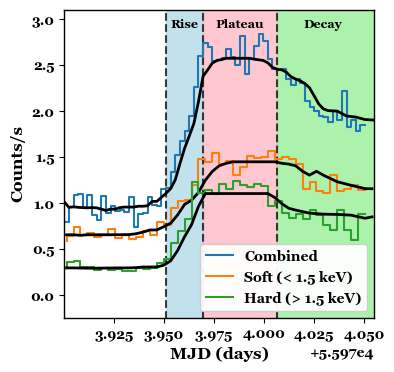

In [11]:
# Flare
flare_x = np.copy(x[x>55973.9])
flare_y = y[x>55973.9]

flare_soft_x = (x_soft[x_soft>55973.9])
flare_soft_y = y_soft[x_soft>55973.9]

flare_hard_x = x_hard[x_hard>55973.9]
flare_hard_y = y_hard[x_hard>55973.9]

# Get rise, plateau, fall times
i_rise = np.where(flare_y > 1.1)[0]
time_rise = flare_x[i_rise[0]]
print('Rise time: ', time_rise)

i_plat =[i for i in range(len(flare_x)) if (flare_y[i] > 2.5 and flare_y[i+1] > 2.5)][0]
time_plat = flare_x[i_plat]

i_end = [i for i in range(len(flare_x)) if (i > i_plat and flare_y[i] < 2.5 and flare_y[i+1] < 2.5)][0]
time_end = flare_x[i_end]

# Print
print('Rise phase: ', round((time_plat - time_rise)*24,3), 'hours')
print('Plateau: ', round((time_end-time_plat)*24,3), 'hours')
print('Decay: >', round((flare_x[-1]-time_end)*24,3), 'hours')

# Plot
plt.figure(figsize=(4,4))

plt.step(flare_x, flare_y, label='Combined')
plt.plot(flare_x, rolling_median(flare_y, 10), c='k', lw=2)

plt.step(flare_soft_x, flare_soft_y, label='Soft (< 1.5 keV)')
plt.plot(flare_soft_x, rolling_median(flare_soft_y, 10), c='k', lw=2)

plt.step(flare_hard_x, flare_hard_y, label='Hard (> 1.5 keV)')
plt.plot(flare_hard_x, rolling_median(flare_hard_y, 10), c='k', lw=2)

plt.vlines([time_rise, time_plat, time_end], -0.5, 3.1, 'k', '--', alpha=0.75, zorder=1)
plt.axvspan(time_rise, time_plat, color='lightblue', alpha=0.75, zorder=0)
plt.axvspan(time_plat, time_end, color='lightpink', alpha=0.75, zorder=0)
plt.axvspan(time_end, flare_x[-1], color='lightgreen', alpha=0.75, zorder=0)

plt.text((time_rise+0.002), 2.9, 'Rise', fontsize=9)
plt.text((time_plat+0.006), 2.9, 'Plateau', fontsize=9)
plt.text((time_end+0.013), 2.9, 'Decay', fontsize=9)

plt.xlim(flare_x[0], flare_x[-1])
plt.ylim(-0.25, 3.1)
plt.xlabel('MJD (days)', fontsize=12)
plt.ylabel('Counts/s', fontsize=12)
plt.legend(loc='lower right', framealpha=0.95)
plt.savefig('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/figure_flare.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1, transparent=True)
plt.show()

## 2002 Lightcurves

In [12]:
# Load 2002 Lightcurves
hdul = fits.open('/Users/woodml/Observing/XMM-Newton/SU_Aur/0101440801/SUAur_0101440801_combined.lc')
lc = Table(hdul[1].data)
x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x = x/tc + xmm
y = np.sum(lc['RATE'], 1)
y_err = np.sum(lc['ERROR'], 1)

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/SU_Aur/0101440801/SUAur_0101440801_combined_soft.lc')
lc_soft = Table(hdul[1].data)
x_soft = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x_soft = x_soft/tc + xmm
y_soft = np.sum(lc_soft['RATE'], 1)
y_err_soft = np.sum(lc_soft['ERROR'], 1)

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/SU_Aur/0101440801/SUAur_0101440801_combined_hard.lc')
lc_hard = Table(hdul[1].data)
x_hard = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x_hard = x_hard/tc + xmm
y_hard = np.sum(lc_hard['RATE'], 1)
y_err_hard = np.sum(lc_hard['ERROR'], 1)

/Users/woodml/anaconda3/envs/ciao-4.15/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [15]:
print(x[0], x[-1])

t0 = 117423319/tc + xmm
t1 = 117446000/tc + xmm  # first flare end
t2 = 117469000/tc + xmm  # second flare start
t3 = 117493000/tc + xmm  # second flare end
t4 = 117506000/tc + xmm # third flare start
t5 = 117526000/tc + xmm # third flare end
t_end = x[-1]

print(t0, t1, t2, t3, t4, t5, t_end)

52173.066147408936 52174.56383259412
52173.06619212963 52173.3287037037 52173.59490740741 52173.87268518518 52174.023148148146 52174.25462962963 52174.56383259412


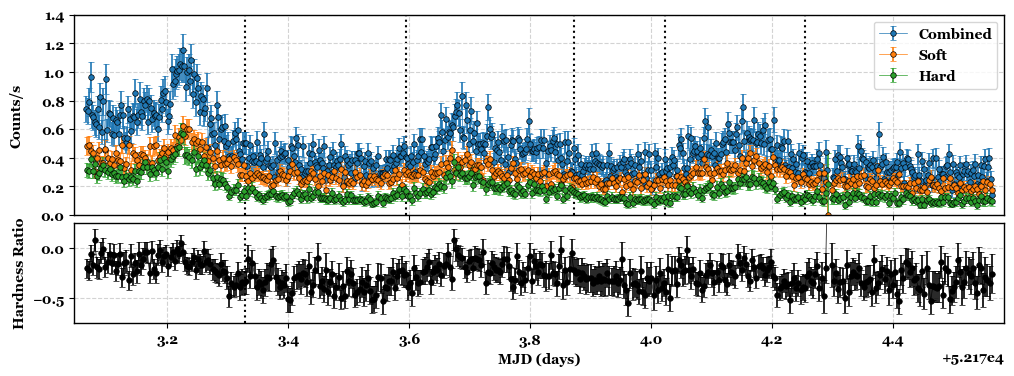

In [16]:
# Plot all SU Aur LCs, 0101440801

# = 2/(x_1+x_2 )^2  np.sqrt(x_2^2 σ_(x_1)^2+ x_1^2 σ_(x_2)^2 )
ratio_err = 2/(y_hard + y_soft)**2 * np.sqrt(y_soft**2*y_err_hard**2 + y_hard**2*y_err_soft**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.05, 'height_ratios':[2,1]}, figsize=(12,4))
ax[0].errorbar(x, y, yerr=y_err, lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(x_soft, y_soft, yerr=y_err_soft, lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft')
ax[0].errorbar(x_hard, y_hard, yerr=y_err_hard, lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard')
ax[0].vlines([t1, t2, t3, t4, t5], 0, 3.5, 'k', ':', zorder=1)
# ax[0].text(
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].set_xlim(x[0]-0.02, x[-1]+0.02)
ax[0].set_ylim(0,1.4)
ax[0].set_ylabel('Counts/s', labelpad=12)
ax[0].legend()

ax[1].errorbar(x_soft, (y_hard-y_soft)/(y_hard+y_soft), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].vlines([117446000/tc + xmm], -0.75, 0.25, 'k', ':', zorder=1)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].set_ylim(-0.75, 0.25)
ax[1].set_xlabel('MJD (days)')
ax[1].set_ylabel('Hardness Ratio')
plt.show()

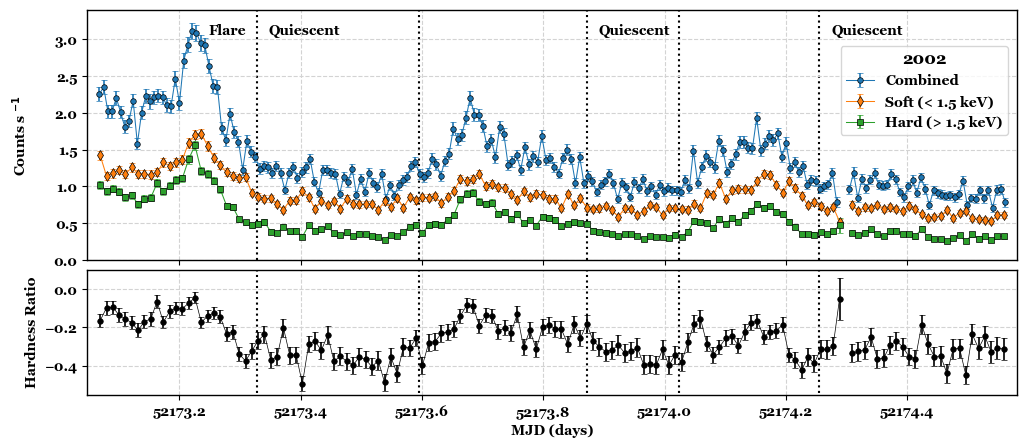

In [27]:
# Plot all SU Aur LCs, 0101440801, binned to 600s
x3 = np.array([np.median(x[i:i+3]) for i in range(0,len(x),3)])
y3 = np.array([np.sum(y[i:i+3]) for i in range(0,len(x),3)])
y_err3 = np.array([np.sum(y_err[i:i+3])/3 for i in range(0,len(x),3)])

xs3 = np.array([np.median(x_soft[i:i+3]) for i in range(0,len(x_soft),3)])
ys3 = np.array([np.sum(y_soft[i:i+3]) for i in range(0,len(x_soft),3)])
ys_err3 = np.array([np.sum(y_err_soft[i:i+3])/3 for i in range(0,len(x_soft),3)])

xh3 = np.array([np.median(x_hard[i:i+3]) for i in range(0,len(x_hard),3)])
yh3 = np.array([np.sum(y_hard[i:i+3]) for i in range(0,len(x_hard),3)])
yh_err3 = np.array([np.sum(y_err_hard[i:i+3])/3 for i in range(0,len(x_hard),3)])

# = 2/(x_1+x_2 )^2  np.sqrt(x_2^2 σ_(x_1)^2+ x_1^2 σ_(x_2)^2 )
ratio_err = 2/(yh3+ys3)**2 * np.sqrt(ys3**2*yh_err3**2 + yh3**2*ys_err3**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.05, 'height_ratios':[2,1]}, figsize=(12,5))
ax[0].errorbar(x3, y3, yerr=y_err3, lw=0.75, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(xs3, ys3, yerr=ys_err3, marker='d', lw=0.75, ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft (< 1.5 keV)')
ax[0].errorbar(xh3, yh3, yerr=yh_err3, marker='s', lw=0.75, ms=3.8, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard (> 1.5 keV)')
ax[0].vlines([t1, t2, t3, t4, t5], 0, 3.5, 'k', ':', zorder=1)
# ax[0].vlines([52173.22, 52173.68, 52174.15], 0, 3.5, 'k', '-', zorder=1)
ax[0].text(0.13, 0.9, 'Flare', transform=ax[0].transAxes)
ax[0].text(0.195, 0.9, 'Quiescent', transform=ax[0].transAxes)
ax[0].text(0.55, 0.9, 'Quiescent', transform=ax[0].transAxes)
ax[0].text(0.8, 0.9, 'Quiescent', transform=ax[0].transAxes)
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax[0].set_xlim(x3[0]-0.02, x3[-1]+0.02)
ax[0].set_ylim(0,3.4)
ax[0].set_ylabel('Counts s $^{-1}$', labelpad=18)
ax[0].legend(loc=(0.81, 0.5), title='2002', title_fontsize=12)

ax[1].errorbar(xs3, (yh3-ys3)/(yh3+ys3), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].vlines([t1, t2, t3, t4, t5], -0.6, 0.15, 'k', ':', zorder=1)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].set_ylim(-0.55, 0.1)
ax[1].set_xlabel('MJD (days)')
ax[1].set_ylabel('Hardness Ratio')
plt.savefig('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/figure_2002_lc.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

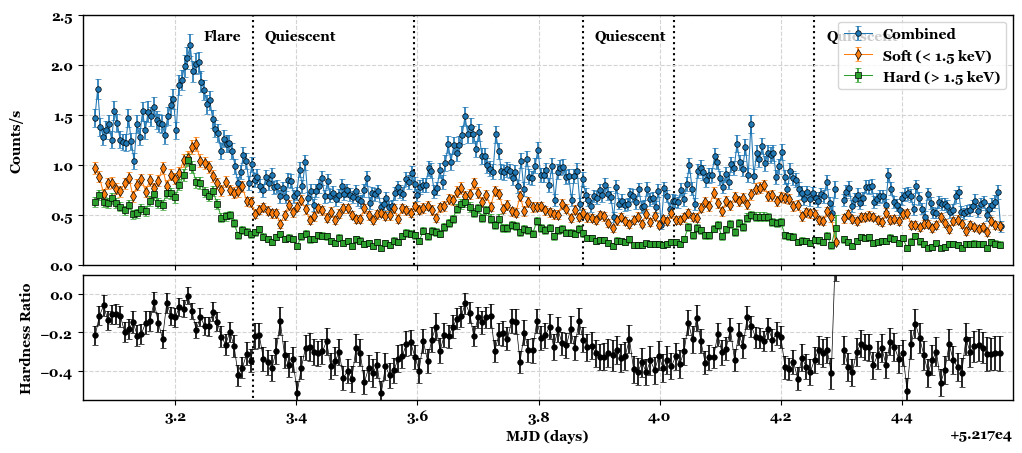

In [28]:
# Plot all SU Aur LCs, 0101440801, binned to 400s
x3 = np.array([np.median(x[i:i+2]) for i in range(0,len(x),2)])
y3 = np.array([np.sum(y[i:i+2]) for i in range(0,len(x),2)])
y_err3 = np.array([np.sum(y_err[i:i+2])/2 for i in range(0,len(x),2)])

xs3 = np.array([np.median(x_soft[i:i+2]) for i in range(0,len(x_soft),2)])
ys3 = np.array([np.sum(y_soft[i:i+2]) for i in range(0,len(x_soft), 2)])
ys_err3 = np.array([np.sum(y_err_soft[i:i+2])/2 for i in range(0,len(x_soft), 2)])

xh3 = np.array([np.median(x_hard[i:i+2]) for i in range(0,len(x_hard),2)])
yh3 = np.array([np.sum(y_hard[i:i+2]) for i in range(0,len(x_hard),2)])
yh_err3 = np.array([np.sum(y_err_hard[i:i+2])/2 for i in range(0,len(x_hard),2)])

# = 2/(x_1+x_2 )^2  np.sqrt(x_2^2 σ_(x_1)^2+ x_1^2 σ_(x_2)^2 )
ratio_err = 2/(yh3+ys3)**2 * np.sqrt(ys3**2*yh_err3**2 + yh3**2*ys_err3**2)

_, ax = plt.subplots(nrows=2, ncols=1, sharex='col', gridspec_kw={'hspace':0.05, 'height_ratios':[2,1]}, figsize=(12,5))
ax[0].errorbar(x3, y3, yerr=y_err3, lw=0.75, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Combined')
ax[0].errorbar(xs3, ys3, yerr=ys_err3, marker='d', lw=0.75, ms=5, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Soft (< 1.5 keV)')
ax[0].errorbar(xh3, yh3, yerr=yh_err3, marker='s', lw=0.75, ms=3.8, markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2, label='Hard (> 1.5 keV)')
ax[0].vlines([t1, t2, t3, t4, t5], 0, 3.5, 'k', ':', zorder=1)
ax[0].text(0.13, 0.9, 'Flare', transform=ax[0].transAxes)
ax[0].text(0.195, 0.9, 'Quiescent', transform=ax[0].transAxes)
ax[0].text(0.55, 0.9, 'Quiescent', transform=ax[0].transAxes)
ax[0].text(0.8, 0.9, 'Quiescent', transform=ax[0].transAxes)
ax[0].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[0].set_xlim(x3[0]-0.02, x3[-1]+0.02)
ax[0].set_ylim(0,2.5)
ax[0].set_ylabel('Counts/s', labelpad=18)
ax[0].legend()

ax[1].errorbar(xs3, (yh3-ys3)/(yh3+ys3), yerr=ratio_err, c='k', lw=0.5, ms=8, marker='.', markeredgecolor='k', markeredgewidth=.5, capsize=2, elinewidth=1.2)
ax[1].vlines([117446000/tc + xmm], -0.6, 0.15, 'k', ':', zorder=1)
ax[1].grid('both','major',c='lightgray',ls='--', zorder=0)
ax[1].set_ylim(-0.55, 0.1)
ax[1].set_xlabel('MJD (days)')
ax[1].set_ylabel('Hardness Ratio')
# plt.savefig('/Users/woodml/Documents/X-Ray/SU Aur/figure_2002_lc.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## Optical + X-Ray LC

55972.88385416666
   HJD       X       Y    ...        Filename       ComparisonID    MJD    
--------- ------- ------- ... --------------------- ------------ ----------
5972.9145 372.065  597.01 ... SUAur_120215_001V.fit            7 55972.9145
5972.9148 371.772 596.711 ... SUAur_120215_002V.fit            7 55972.9148
5972.9151 371.723 595.876 ... SUAur_120215_003V.fit            7 55972.9151
      ...     ...     ... ...                   ...          ...        ...
5973.0475  546.88 398.588 ... SUAur_120215_375V.fit            7 55973.0475
5973.0479 546.988 398.609 ... SUAur_120215_376V.fit            7 55973.0479
5973.0482 546.823 398.757 ... SUAur_120215_377V.fit            7 55973.0482
5973.0486 546.631 398.518 ... SUAur_120215_378V.fit            7 55973.0486
Length = 378 rows


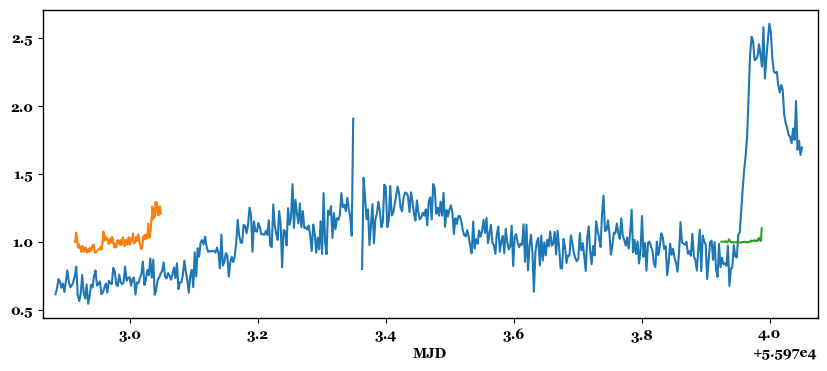

In [231]:
# XMM-Newton
hdul = fits.open('/Users/woodml/Observing/XMM-Newton/SU_Aur/0671960101/SUAur_combined_lc.lc')
lc = Table(hdul[1].data)
x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x = x/3600/24
x = x + 50814.0
print(x[0])

y = np.sum(lc['RATE'], 1)
y = y/np.nanmedian(y)

# Optical
optical = Table.read('/Users/woodml/Observing/other/SU Aur/other/SUABAur/SUAur_V/SUv00003.dat', format='ascii', delimiter='\t', fast_reader=False, guess=False)
optical['MJD'] = optical['HJD'] + 50000.

mids = [55970.5, 55971.5, 55972.5, 55973.5, 55974.5, 55975.5, 55976.5]
optical = [optical[[mids[i] < x < mids[i+1] for x in optical['MJD']]] for i in range(len(mids)-1)]
print(optical[2])

plt.figure(figsize=(10,4))
plt.plot(x, y)
plt.plot(optical[2]['MJD'], optical[2]['Mag']/np.median(optical[2]['Mag']))
plt.plot(optical[3]['MJD'], optical[3]['Mag']/np.median(optical[3]['Mag']))

plt.xlabel('MJD')
plt.xlim(x[0]-0.02, x[-1]+0.02)
plt.show()

In [232]:
xmm = Time(50814.0, format='mjd')
print(xmm)  # XMM Newton Reference time
print((xmm+5158*u.day).isot)

50814.0
2012-02-14T23:59:57.000


# Timing

In [53]:
# X-ray Observations
tc = 60*60*24  # convert to days
xmm = 50814.0  # XMM Newton Reference time 

hdul = fits.open('/Users/woodml/Observing/XMM-Newton/SU_Aur/0671960101/SUAur_combined_lc.lc')
lc = Table(hdul[1].data)
x = np.arange(hdul[1].header['TSTART'], hdul[1].header['TSTOP'], hdul[1].header['TIMEDEL'])
x = x/tc + xmm
x_ray_start = x[0]
x_ray_end = x[-1]
print(x_ray_start, x_ray_end)

55972.88385416666 55974.05515046296


In [54]:
# ARAS Observations
aras_starts = []
aras_ends = []
files = glob.glob('/Users/woodml/Observing/other/SU & AB Aur/ARAS/spectrum-aras/*.fit')
files.sort()
for file in files:
    hdul = fits.open(file)
    data = hdul[0].data
    hdr = hdul[0].header

    aras_starts.append(Time(hdr['DATE-OBS']).mjd)
    aras_ends.append((Time(hdr['DATE-OBS']) + hdr['EXPTIME']*u.s).mjd)

print(aras_starts, aras_ends)

[55968.76758101852, 55968.807754629626, 55968.81888888889, 55969.766168981485, 55969.82417824074, 55970.84232638889, 55971.829247685186, 55972.849016203705, 55973.847546296296, 55974.80520833333, 55975.75699074074, 55975.837847222225, 55977.76284722222] [55968.81921296296, 55968.8752662037, 55968.87097222222, 55969.84305555555, 55969.87626157407, 55970.911770833336, 55971.895219907405, 55972.90109953703, 55973.89962962963, 55974.85729166667, 55975.822164351855, 55975.88993055555, 55977.83950231481]


In [58]:
# FAST Observations
fast_starts = []
fast_ends = []
files = glob.glob('/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/*stack_spectra.fits')
files.sort()
for file in files:
    hdul = fits.open(file)
    data = hdul[0].data
    hdr = hdul[0].header

    fast_starts.append(Time(hdr['TSTART'], format='mjd').mjd)
    fast_ends.append(Time(hdr['TEND'], format='mjd').mjd)

print(fast_starts, fast_ends)

[55973.07273148148, 55973.183344907404, 55976.06715277778, 55976.17190972222, 55977.06725694444, 55978.06684027778, 55978.19298611111, 55979.06715277778] [55973.07350694444, 55973.18482638889, 55976.06949074074, 55976.17356481482, 55977.06886574074, 55978.06966435185, 55978.19458333333, 55979.068761574075]


In [108]:
# TRES Observation
hdul = fits.open('/Users/woodml/Observing/other/SU & AB Aur/FLWO/TRES/SU-Aur_2012-02-15_07h24m57s_cb.spec.fits')
hdr = hdul[0].header
# print(hdr.keys)

tres_start = Time(hdr['DATE-OBS'])
tres_end = tres_start + hdr['EXPTIME']*u.s

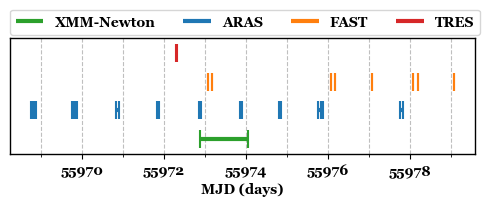

In [119]:
# Plot
fig = plt.figure(figsize=(6,1.5))
ax = fig.gca()

# XMM-Newton
plt.hlines([1], x_ray_start, x_ray_end, color='C2', lw=3, label='XMM-Newton')
plt.scatter([x_ray_start, x_ray_end], [1, 1], marker='|', s=180, c='C2')

# ARAS
plt.hlines([2], aras_starts[0], aras_ends[0], 'C0', lw=3, label='ARAS')
for i in range(1, len(aras_starts)):
    plt.hlines([2], aras_starts[i], aras_ends[i], 'C0', lw=3)
plt.scatter([aras_starts, aras_ends], [2]*(len(aras_starts)*2), marker='|', s=180, c='C0')

# FAST
plt.hlines([3], fast_starts[0], fast_ends[0], 'C1', lw=3, label='FAST')
for i in range(1, len(fast_starts)):
    plt.hlines([3], fast_starts[i], fast_ends[i], 'C1', lw=3)
plt.scatter([fast_starts, fast_ends], [3]*(len(fast_starts)*2), marker='|', s=180, c='C1')

# TRES
plt.hlines([4], tres_start.mjd, tres_end.mjd, color='C3', lw=3, label='TRES')
plt.scatter([tres_start.mjd, tres_end.mjd], [4, 4], marker='|', s=180, c='C3')

# Plot formatting
plt.xlabel('MJD (days)')
plt.grid('both', 'both', c='gray', ls='--', alpha=0.5, zorder=-1)
plt.yticks([],[])
plt.xticks([55969, 55971, 55973, 55975, 55977, 55979],[], minor=True)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # remove the addition at the end, so full tick values are written

plt.ylim(.5, 4.5)
plt.legend(loc=(0, 1.03), ncols=4)
plt.savefig('/Users/woodml/Documents/X-Ray/SU Aur/figure_timing.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

# Comparing Models

In [10]:
all_models = Table.read('model_fits.txt', format='ascii', fast_reader=False, delimiter='\t', guess=False)
all_models[:20].pprint_all()
robrade_2002 = all_models[2:15]
print(robrade_2002)

     Parameter        Value   
------------------- ----------
               2002          .
 Abudances: Robrade          .
            abs1.nH   0.101996
              v1.kT   0.780724
              v2.kT     1.7577
              v3.kT    4.22483
            v1.norm 1.97837E-4
            v2.norm 4.32217E-4
            v3.norm 5.17986E-4
               v1.O    1.38498
              v1.Ne     3.5393
              v1.Mg    2.29256
              v1.Si    1.16947
              v1.Fe    1.18827
               Chi2    1.62162
               2012          .
Abundances: Robrade          .
            abs1.nH   0.124446
              v1.kT    0.61747
              v2.kT   0.991698
Parameter  Value  
--------- --------
  abs1.nH 0.101996
    v1.kT 0.780724
    v2.kT   1.7577
      ...      ...
    v1.Mg  2.29256
    v1.Si  1.16947
    v1.Fe  1.18827
     Chi2  1.62162
Length = 13 rows


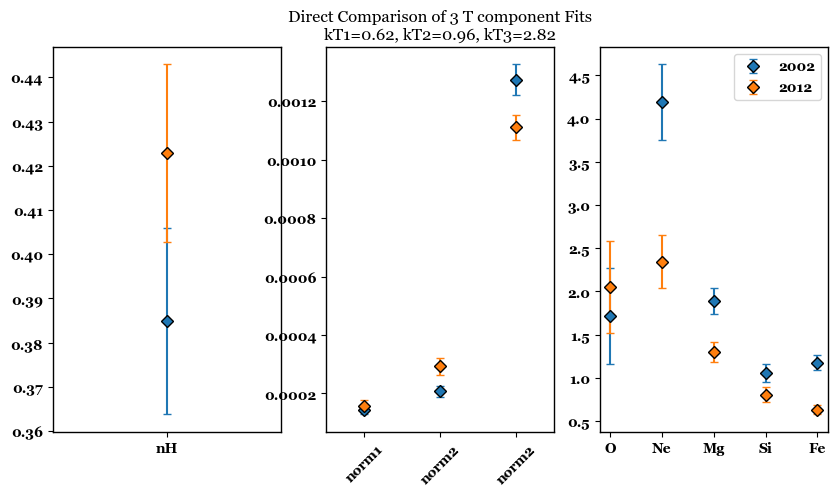

In [11]:
# Comparing 2002 vs 2012, Asplund, 3T
a = [0.384897,1.43135e-4,2.06792e-4,1.27297e-3,1.718,4.189,1.887,1.055,1.176] # 2002, Asplund, 3T, T's locked
e_a = [0.0211278, 1.51525e-5, 1.93015e-5,5.24948e-5,0.555181,0.436373,0.150565,0.109308,0.0877288]
b = [0.422829,1.55455e-4,2.92752e-4,1.1108e-3,2.051,2.344,1.298,0.804,0.627]  # 2012, Asplund, 3T, T's locked
e_b = [0.0200837, 2.05625e-5, 3.01895e-5, 4.31492e-5, 0.532843, 0.308425, 0.118998, 0.0882004, 0.0527734]

x = range(len(a))

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5), gridspec_kw={'wspace':0.2})
ax[0].errorbar(x[:1], a[:1], yerr=e_a[:1], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[0].errorbar(x[:1], b[:1], yerr=e_b[:1], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[0].set_xlim(-0.05, 0.05)
ax[0].set_xticks([0], labels=['nH'])
ax[1].errorbar(x[1:4], a[1:4], yerr=e_a[1:4], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[1].errorbar(x[1:4], b[1:4], yerr=e_b[1:4], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[1].set_xlim(0.5, 3.5)
ax[1].set_xticks([1,2,3], labels=['norm1','norm2','norm2'], rotation=45)
ax[2].errorbar(x[4:], a[4:], yerr=e_a[4:], marker='D', ls='None', capsize=3, markeredgecolor='k', label='2002')
ax[2].errorbar(x[4:], b[4:], yerr=e_b[4:], marker='D', ls='None', capsize=3, markeredgecolor='k', label='2012')
ax[2].set_xticks([4,5,6,7,8],labels=['O','Ne','Mg','Si','Fe'])
plt.legend(loc='upper right')
ax[1].set_title('Direct Comparison of 3 T component Fits\nkT1=0.62, kT2=0.96, kT3=2.82')
plt.show()

14
14
14


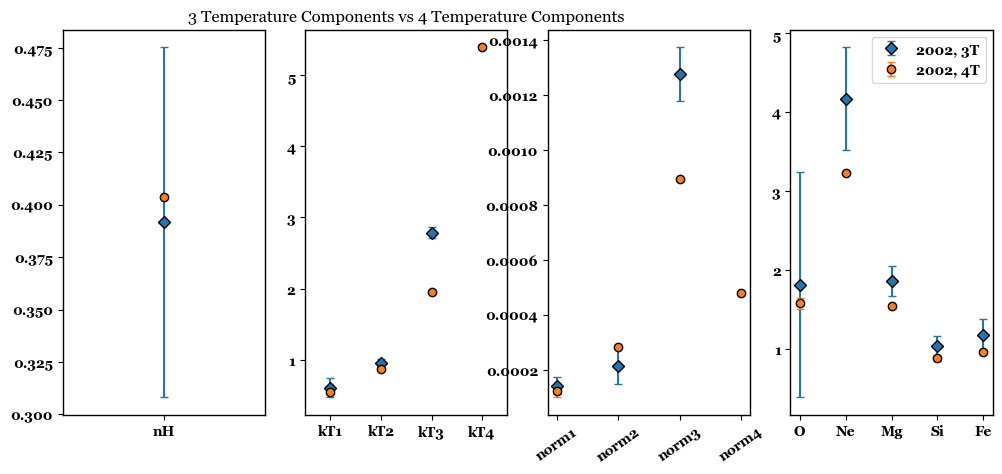

In [41]:
a =   [0.39171,  0.609949,0.951412,    2.7831,    float('nan'),1.41041e-4,2.12765e-4,1.27698e-3, float('nan'),1.81068,4.16607,1.85252,1.03526,1.17649]
e_a = [0.0835608,0.136082,0.0572764,   0.0767677, float('nan'),3.04449e-5,6.51404e-5,9.78322e-5, float('nan'),1.42606,0.649986,0.189309,0.125441,0.200203]
b =   [0.403812, 0.543607,0.86311,     1.9463,    5.38872,1.2024e-4,2.82886e-4,8.93945e-4,4.80419e-4,1.57467,3.22717,1.5347,0.876648,0.952462]
e_b = [float('nan'),0.0164912,0.011941,0.0275718, float('nan'),2.08337e-5,float('nan'),float('nan'),float('nan'),0.0699166,float('nan'),float('nan'),0.0288375,float('nan')]
c = 
e_c = 
d = 
e_d = 

x = range(len(a))
print(len(a))
print(len(b))
print(len(e_b))

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(12,5), gridspec_kw={'wspace':0.2})
ax[0].errorbar(x[:1], a[:1], yerr=e_a[:1], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[0].errorbar(x[:1], b[:1], yerr=e_b[:1], marker='o', ls='None', capsize=3, markeredgecolor='k')
ax[0].set_xlim(-0.05, 0.05)
ax[0].set_xticks([0], labels=['nH'])
ax[1].errorbar(x[1:5], a[1:5], yerr=e_a[1:5], marker='D', ls='None', capsize=3, markeredgecolor='k')
ax[1].errorbar(x[1:5], b[1:5], yerr=e_b[1:5], marker='o', ls='None', capsize=3, markeredgecolor='k')
ax[1].set_xlim(0.5, 4.5)
ax[1].set_xticks([1,2,3,4], labels=['kT1','kT2','kT3','kT4'])
ax[2].errorbar(x[5:9], a[5:9], yerr=e_a[5:9], marker='D', ls='None', capsize=3, markeredgecolor='k', label='2002')
ax[2].errorbar(x[5:9], b[5:9], yerr=e_b[5:9], marker='o', ls='None', capsize=3, markeredgecolor='k', label='2012')
ax[2].set_xticks([5,6,7,8],labels=['norm1','norm2','norm3','norm4'], rotation=35)
ax[3].errorbar(x[9:], a[9:], yerr=e_a[9:], marker='D', ls='None', capsize=3, markeredgecolor='k', label='2002, 3T')
ax[3].errorbar(x[9:], b[9:], yerr=e_b[9:], marker='o', ls='None', capsize=3, markeredgecolor='k', label='2002, 4T')
ax[3].set_xticks([9,10,11,12,13],labels=['O','Ne','Mg','Si','Fe'])
plt.legend(loc='upper right')
ax[1].set_title('3 Temperature Components vs 4 Temperature Components')
plt.show()

# Spectral Fit Results

## Global Fit Table

In [6]:
# Load results
quiet_2002 = Table.read('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/2002_quiet_fit_results.txt', format='latex')

flare_2002 = Table.read('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/2002_flare_fit_results.txt', format='latex')

quiet_2012 = Table.read('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/2012_quiet_fit_results.txt', format='latex')

flare_2012 = Table.read('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/2012_flare_fit_results.txt', format='latex')

In [1]:
# Create Latex Table

# Create new table, remove uncessary rows
final_fit = vstack([row for row in quiet_2002 if ('kT' not in row['Parameter']) and ('norm' not in row['Parameter']) and ('redshift' not in row['Parameter'])])

# Concatentate
final_fit.rename_columns(['Value','e_lower','e_upper'],['value_2002','e_lower_2002','e_upper_2002'])

temp = vstack([row for row in flare_2002 if ('kT' not in row['Parameter']) and ('norm' not in row['Parameter']) and ('redshift' not in row['Parameter'])])
temp1 = vstack([row for row in quiet_2012 if ('kT' not in row['Parameter']) and ('norm' not in row['Parameter']) and ('redshift' not in row['Parameter'])])
print(temp1)
temp2 = vstack([row for row in flare_2012 if ('kT' not in row['Parameter']) and ('norm' not in row['Parameter']) and ('redshift' not in row['Parameter'])])

final_fit = hstack([final_fit, temp, temp1, temp2])

# print(final_fit['Parameter_1','Parameter_2','Parameter_3','Parameter_4'])
print(final_fit.colnames)

final_fit.remove_columns(['Parameter_2', 'Parameter_3', 'Parameter_4'])
final_fit.rename_columns(['Parameter_1', 'Value_2','e_lower_2','e_upper_2'],['Parameter','value_2002_flare','e_lower_2002_flare','e_upper_2002_flare'])
final_fit.rename_columns(['Value_3','e_lower_3','e_upper_3'],['value_2012','e_lower_2012','e_upper_2012'])
final_fit.rename_columns(['Value_4','e_lower_4','e_upper_4'],['value_2012_flare','e_lower_2012_flare','e_upper_2012_flare'])

# Format errors
final_fit['2002'] = [('$' + str(row['value_2002']) + '\pm' + str(row['e_upper_2002']) + '$') if (abs(row['e_lower_2002']) == row['e_upper_2002']) else ('$' + str(row['value_2002']) + '_{' + str(row['e_lower_2002']) + '}^{+' + str(row['e_upper_2002']) +'}$') for row in final_fit]

final_fit['2002_Flare'] = [('$' + str(row['value_2002_flare']) + '\pm' + str(row['e_upper_2002_flare']) + '$') if (abs(row['e_lower_2002_flare']) == row['e_upper_2002_flare']) else ('$' + str(row['value_2002_flare']) + '_{' + str(row['e_lower_2002_flare']) + '}^{+' + str(row['e_upper_2002_flare']) +'}$') for row in final_fit]

final_fit['2012'] = [('$' + str(row['value_2012']) + '\pm' + str(row['e_upper_2012']) + '$') if (abs(row['e_lower_2012']) == row['e_upper_2012']) else ('$' + str(row['value_2012']) + '_{' + str(row['e_lower_2012']) + '}^{+' + str(row['e_upper_2012']) +'}$') for row in final_fit]

final_fit['2012_Flare'] = [('$' + str(row['value_2012_flare']) + '\pm' + str(row['e_upper_2012_flare']) + '$') if (abs(row['e_lower_2012_flare']) == row['e_upper_2012_flare']) else ('$' + str(row['value_2012_flare']) + '_{' + str(row['e_lower_2012_flare']) + '}^{+' + str(row['e_upper_2012_flare']) +'}$') for row in final_fit]

# Remove extra columns
final_fit = final_fit['Parameter','2002','2002_Flare','2012','2012_Flare']

# Remove extra elements
# final_fit = vstack([row for row in final_fit if (row['Parameter'] != 'v1.C') and (row['Parameter'] != 'v1.He') and (row['Parameter'] != 'v1.N') and (row['Parameter'] != 'v1.S') and (row['Parameter'] != 'v1.Ar') and (row['Parameter'] != 'v1.Ni') and (row['Parameter'] != 'v1.Al') and (row['Parameter'] != 'v1.Ca')])
final_fit = vstack([row for row in final_fit if row['Parameter'] not in ['v1.C','v1.He','v1.N','v1.S','v1.Ar','v1.Ni','v1.Al','v1.Ca']])

# Fix Parameter Names
for row in final_fit:
    if row['Parameter'] == 'abs1.nH':
        row['Parameter'] = '$N_{H_1}$'
    elif row['Parameter'] == 'abs2.nH':
        row['Parameter'] = '$N_{H_2}$'
    elif row['Parameter'] == 'v1.EM':
        row['Parameter'] = '$EM_1$'
    elif row['Parameter'] == 'v2.EM':
        row['Parameter'] = '$EM_2$'
    elif row['Parameter'] == 'v3.EM':
        row['Parameter'] = '$EM_3$'
    elif row['Parameter'] == 'v1.T':
        row['Parameter'] = '$T_1$'
    elif row['Parameter'] == 'v2.T':
        row['Parameter'] = '$T_2$'
    elif row['Parameter'] == 'v3.T':
        row['Parameter'] = '$T_3$'
    elif row['Parameter'] == 'v1.O':
        row['Parameter'] = 'C, N, O'
    elif row['Parameter'] == 'v1.Ne':
        row['Parameter'] = 'Ne'
    elif row['Parameter'] == 'v1.Mg':
        row['Parameter'] = 'Mg, Ni'
    elif row['Parameter'] == 'v1.Si':
        row['Parameter'] = 'Si'
    elif row['Parameter'] == 'v1.Fe':
        row['Parameter'] = 'Fe, Ca, Al, Mg, Ni, Si'

final_fit.pprint_all()
final_fit.write('/Users/woodml/Documents/X-Ray/TaleofTwoStars/SU_Aur/final_fit_results.txt', format='latex', overwrite=True)

NameError: name 'vstack' is not defined

## Plotting Abundances

In [6]:
q02 = quiet_2002
f02 = flare_2002
q12 = quiet_2012
f12 = flare_2012

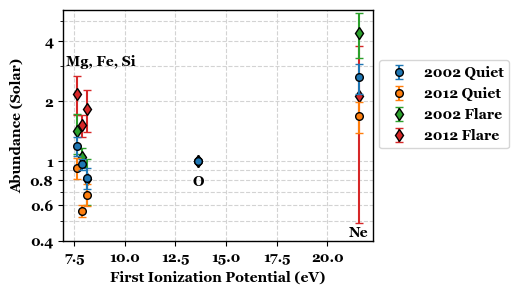

In [39]:
# Plotting abundances
# O, Ne, Mg, Si, Fe
a_q02 = [q02[q02['Parameter']==x]['Value'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]
a_q02_err = [q02[q02['Parameter']==x]['e_upper'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]

a_f02 = [f02[f02['Parameter']==x]['Value'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]
a_f02_err = [f02[f02['Parameter']==x]['e_upper'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]

a_q12 = [q12[q12['Parameter']==x]['Value'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]
a_q12_err = [q12[q12['Parameter']==x]['e_upper'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]

a_f12 = [f12[f12['Parameter']==x]['Value'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]
a_f12_err = [f12[f12['Parameter']==x]['e_upper'][0] for x in ['v1.O','v1.Ne','v1.Mg','v1.Si','v1.Fe']]

fips = [13.618, 21.565, 7.646, 8.152, 7.902]
_, ax = plt.subplots(figsize=(4,3))
plt.errorbar(fips, a_q02, yerr=a_q02_err, marker='o', ls='None', ms=5.5, capsize=3, markeredgecolor='k', label='2002 Quiet', zorder=10)
plt.errorbar(fips, a_q12, yerr=a_q12_err, marker='o', ls='None', ms=5.5, capsize=3, markeredgecolor='k', label='2012 Quiet', zorder=8)
plt.errorbar(fips, a_f02, yerr=a_f02_err, marker='d', ls='None', ms=6, capsize=3, markeredgecolor='k', label='2002 Flare', zorder=4)
plt.errorbar(fips, a_f12, yerr=a_f12_err, marker='d', ls='None', ms=6, capsize=3, markeredgecolor='k', label='2012 Flare', zorder=3)
plt.text(8.8, 3., 'Mg, Fe, Si', horizontalalignment='center')
plt.text(13.618, 0.75, 'O', horizontalalignment='center')
plt.text(21.565, 0.42, 'Ne', horizontalalignment='center')
plt.legend(loc=(1.02, 0.4))
plt.yscale('log')
ax.set_ylim(0.4,5.7)
ax.set_yticks([0.4,0.6,0.8,1.,2,4], minor=False)
ax.set_yticklabels(['0.4','0.6','0.8','1','2','4'])
ax.set_yticks([0.5, 0.7, 0.9, 3,5], minor=True)
plt.xlabel('First Ionization Potential (eV)')
plt.ylabel('Abundance (Solar)')
plt.grid('major','both',c='lightgray',ls='--', zorder=0)
plt.savefig('/Users/woodml/Documents/X-Ray/SU Aur/figure_fip.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

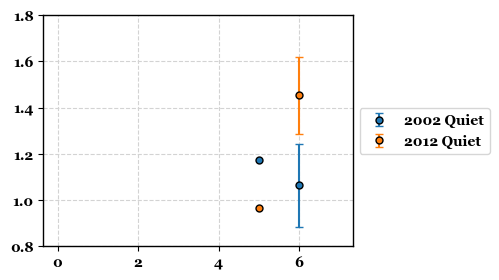

In [8]:
# Plotting abundances
param_list = ['abs1.nH', 'abs2.nH', 'v1.T', 'v2.T','v3.T', 'v1.EM','v2.EM','v3.EM']

a_q02 = [q02[q02['Parameter']==x]['Value'][0] for x in param_list]
a_q02_err = [q02[q02['Parameter']==x]['e_upper'][0] for x in param_list]

a_f02 = [f02[f02['Parameter']==x]['Value'][0] for x in param_list]
a_f02_err = [f02[f02['Parameter']==x]['e_upper'][0] for x in param_list]

a_q12 = [q12[q12['Parameter']==x]['Value'][0] for x in param_list]
a_q12_err = [q12[q12['Parameter']==x]['e_upper'][0] for x in param_list]

a_f12 = [f12[f12['Parameter']==x]['Value'][0] for x in param_list]
a_f12_err = [f12[f12['Parameter']==x]['e_upper'][0] for x in param_list]

fips = range(len(param_list))
plt.figure(figsize=(4,3))
plt.errorbar(fips, a_q02, yerr=a_q02_err, marker='o', ls='None', ms=5, capsize=3, markeredgecolor='k', label='2002 Quiet', zorder=10)
plt.errorbar(fips, a_q12, yerr=a_q12_err, marker='o', ls='None', ms=5, capsize=3, markeredgecolor='k', label='2012 Quiet', zorder=4)
# plt.errorbar(fips, a_f02, yerr=a_f02_err, marker='D', ls='None', ms=5, capsize=3, markeredgecolor='k', label='2002 Flare', zorder=4)
# plt.errorbar(fips, a_f12, yerr=a_f12_err, marker='D', ls='None', ms=5, capsize=3, markeredgecolor='k', label='2012 Flare', zorder=3)
plt.legend(loc=(1.02, 0.4))
plt.ylim(0.8,1.8)
# plt.xlabel('First Ionization Potential (eV)')
# plt.ylabel('Abundance (Solar)')
plt.grid('major','both',c='lightgray',ls='--', zorder=0)
# plt.savefig('/Users/woodml/Documents/X-Ray/SU Aur/figure_fip.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

# H $\alpha$

In [96]:
def convert_time_to_y(time, t0, t1, y0, y1):

    # # First file
    # hdul = fits.open(first_file)
    # t0 = Time(hdul[0].header['DATE-OBS']).mjd

    # x = np.arange(hdul[0].header['CRVAL1'], hdul[0].header['CRVAL1']+(hdul[0].header['CDELT1']*hdul[0].header['NAXIS1']), hdul[0].header['CDELT1'])
    # mask = [True if 6538 < j < 6582 else False for j in x]
    # data = hdul[0].data

    # y0 = (data/np.max(data))[mask][0] - 0.25

    # # Last file
    # hdul = fits.open(last_file)
    # t1 = Time(hdul[0].header['DATE-OBS']).mjd

    # x = np.arange(hdul[0].header['CRVAL1'], hdul[0].header['CRVAL1']+(hdul[0].header['CDELT1']*hdul[0].header['NAXIS1']), hdul[0].header['CDELT1'])
    # mask = [True if 6538 < j < 6582 else False for j in x]
    # data = hdul[0].data

    # y1 = (data/np.max(data))[mask][0] + 2.75

    # All
    # print(t0, ',', t1)
    # print('Part 1: ', time - t0)

    # print('Part 2: ', (y1-y0)/(t1-t0))
    # print(y0, ',', y1)
    # print((y1-y0)/(t1-t0) * (time - t0) + y0)
    
    return (y1-y0)/(t1-t0) * (time - t0) + y0

In [4]:
def find_continuum(wavelength, flux, window, line):
    # Separate the window, line, left and right sides
    window_mask = [True if window[0] < x < window[1] else False for x in wavelength]

    left_side = [True if window[0] < x < line[0] else False for x in wavelength]
    right_side = [True if line[1] < x < window[1] else False for x in wavelength]

    # Fit a line (1st order poly) to the window
    x1 = np.nanmedian(wavelength[left_side])
    y1 = np.nanmedian(flux[left_side])
    x2 = np.nanmedian(wavelength[right_side])
    y2 = np.nanmedian(flux[right_side])

    pseudo = (y2-y1)/(x2-x1)*(wavelength-x1)+y1
    
    return pseudo

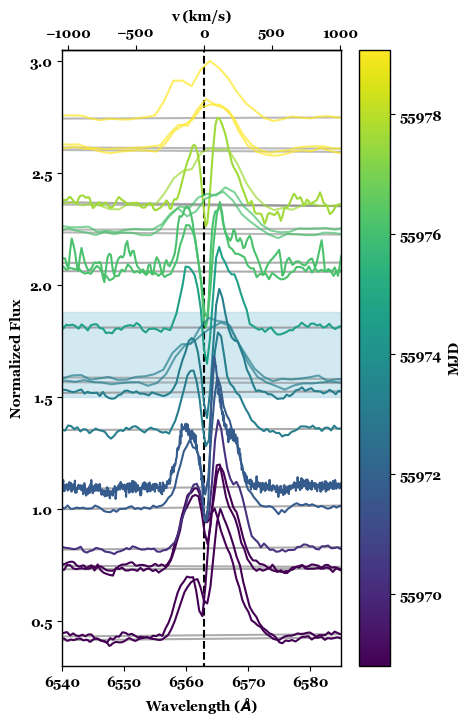

In [103]:
# Plot all Halpha Spectra

# 1. Get all spectra files
aras = glob.glob('/Users/woodml/Observing/other/SU & AB Aur/ARAS/spectrum-aras/*.fit')
aras.sort()
fast = glob.glob('/Users/woodml/Observing/other/SU & AB Aur/FLWO/FAST/*stack_spectra.fits')
fast.sort()

# 2. Set up colorscale
t0 = Time(fits.open(aras[1])[0].header['DATE-OBS']).mjd
t1 = Time(fits.open(fast[-1])[0].header['TSTART'], format='mjd').mjd
viridis = matplotlib.colormaps['viridis'].resampled(8)

hdul = fits.open(aras[1])
x = np.arange(hdul[0].header['CRVAL1'], hdul[0].header['CRVAL1']+(hdul[0].header['CDELT1']*hdul[0].header['NAXIS1']), hdul[0].header['CDELT1'])
mask = [True if 6538 < j < 6582 else False for j in x]
data = hdul[0].data
y0 = (data/np.max(data))[mask][0] - 0.25

hdul = fits.open(fast[-1])
data = Table(hdul[1].data)
mask = [True if 6538 < j < 6582 else False for j in data['wv(Ang)']]
y1 = (data['Flux']/np.max(data['Flux']))[mask][0] + 2.75

# 3. Load ARAS Spectra
aras_wave = []
aras_y = []
aras_continuum = []
aras_time = []
#    a. Loop through files
for file in aras[1:]:  # skipping the first one cause it's bad
    hdul = fits.open(file)
    data = hdul[0].data
    hdr = hdul[0].header

    time = Time(hdr['DATE-OBS'])

    # b. calculate wavelength array using header info
    wave = np.arange(hdr['CRVAL1'], hdr['CRVAL1']+(hdr['CDELT1']*hdr['NAXIS1']), hdr['CDELT1'])
    if len(wave) != len(hdul[0].data): wave = wave[:-1]

    # c. Calculate y-axis values using time
    y = (data/np.max(data) + 2*(time.mjd-t0)/(t1-t0))
    
    # d. Calculate continuum
    continuum = find_continuum(wave, y, [6540,6585], [6554.8, 6570.8])
    aras_wave.append(wave)
    aras_y.append(y)
    aras_continuum.append(continuum)
    aras_time.append(time.mjd)

# 4. Load FAST Spectra
fast.sort()
fast_wave = []
fast_y = []
fast_continuum = []
fast_time = []
#    a. Loop through files
for file in fast:
    hdul = fits.open(file)
    data = Table(hdul[1].data)
    hdr = hdul[0].header

    time = Time(hdr['MJD'], format='mjd')

    # c. Calculate y-axis values using time
    y = (data['Flux']/np.max(data['Flux']) + 2*(time.mjd-t0)/(t1-t0))
    
    # d. Calculate continuum
    continuum = find_continuum(data['wv(Ang)'], y, [6540,6585], [6554.8, 6570.8])
    fast_wave.append(data['wv(Ang)'])
    fast_y.append(y)
    fast_continuum.append(continuum)
    fast_time.append(time.mjd)

# 5. Load TRES Spectrum
tres_spec = Table.read('/Users/woodml/Observing/other/SU & AB Aur/FLWO/TRES/SU_Aur_Halpha.txt', format='ascii')
tres_time = Time('2012-02-15T07:24:5')
#    a. Convert to time related y-axis
tres_y = tres_spec['flux']/np.max(tres_spec['flux']) + 2*(tres_time.mjd-t0)/(t1-t0)
#    b. Calculate TRES Continuum
tres_continuum = find_continuum(tres_spec['wave'], tres_y, [6540,6585], [6554.8, 6570.8])

# 6. Create Plot
fig, ax = plt.subplots(figsize=(4.5,8))
#    a. Plot ARAS Spectra
[plt.plot(aras_wave[i], aras_y[i], c=viridis((aras_time[i]-t0)/(t1-t0))) for i in range(len(aras)-1)]
[plt.plot(aras_wave[i], aras_continuum[i], c='gray', alpha=0.65, zorder=0) for i in range(len(aras)-1)]

#    b. Add TRES spectrum and continuum
plt.plot(tres_spec['wave'], tres_continuum, c='gray', alpha=0.65, zorder=0)
plt.plot(tres_spec['wave'], tres_y, c = viridis((tres_time.mjd-t0)/(t1-t0)))

#    c. Add FAST spectra and continuum 
[plt.plot(fast_wave[i], fast_y[i], c=viridis((fast_time[i]-t0)/(t1-t0)), alpha=0.7) for i in range(len(fast))]
[plt.plot(fast_wave[i], fast_continuum[i], c='gray', alpha=0.55, zorder=0) for i in range(len(fast))]

#    d. Add secondary x-axis
def wave_to_v(wave):
    dw = wave - 6562.8
    return c.c.to('km/s').value* dw/wave
def v_to_wave(v):
    return (c.c.to('km/s').value*6562.8)/(c.c.to('km/s').value - v)

secax = ax.secondary_xaxis('top', functions=(wave_to_v, v_to_wave))
secax.set_xlabel('v (km/s)')

#    e. Shade XMM-Newton and flare
a1 = convert_time_to_y(x_obs_start, t0, t1, y0, y1)
a2 = convert_time_to_y(55973.9, t0, t1, y0, y1)   # flare start
a3 = convert_time_to_y(x_end, t0, t1, y0, y1)

plt.fill_between(np.arange(6540, 6600), a1, a3, color='lightblue', alpha=0.55, zorder=-1)
# plt.fill_between(np.arange(6540, 6600), a2, a3, color='lightpink', alpha=0.55, zorder=-1)
    

#    f. Add colorbar
fig.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(t0, t1), cmap='viridis'), ax=ax, orientation='vertical', format=ScalarFormatter(useOffset=False), label='MJD')
#    g. Set plot parameters
plt.xlim(6540, 6585)
plt.ylim(0.3, 3.05)
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Normalized Flux')
plt.vlines([6562.8], 0, 3.5, 'k','--', zorder=0)
plt.savefig('/Users/woodml/Documents/X-Ray/SU Aur/figure_halpha.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## Echelle Spectra

In [7]:
import string
import re

import numpy as np

import astropy.io.fits as fits
from astropy.wcs import WCS
from specutils import Spectrum1D

class IrafFormatError(Exception):
    '''
    '''
    pass

'''
Missing important things
onedspec format
LTM, CD keywords, CDELT
'''

### implement several possible dispersion functions
def polynomial(func, spec):
    '''Evaluate polynomial dispersion functions
    
    IRAF defines two possible polynomials: Chebyshev and Legendre
    
    Parameters
    ----------
    func : function
        Possible functions are Chebyshev and Legendre
    spec : list of strings
        This is split from the "specN= A B C ..." string in a fits header,
        that defines the WCS to use
    
    Returns
    -------
    pmin, pmax: integer
        min and max coordinate descibed by this dispersion relation
        in physical pixles
    result : np.array
       wavelengths calculated form the dispersion relation
    '''
    order = int(spec.pop(0))
    pmin = int(float(spec.pop(0)))
    pmax = int(float(spec.pop(0)))
    n = np.linspace(-1,1,pmax-pmin+1)
    temp = np.zeros((pmax-pmin+1, order), dtype = float)
    temp[:,0] = 1.
    temp[:,1] = n
    for i in np.arange(2,order):
        temp[:,i] = func(n, i, temp)
    for i in np.arange(0,order):
        temp[:,i] = float(spec.pop(0)) * temp[:,i]
    return pmin, pmax, temp.sum(axis=1)

def chebyshev(n, i, temp):
    '''Iterative definition of Chebyshev polynomial
    
    Implented here from the iraf.noao.onddspec documentation
    see http://iraf.net/irafdocs/specwcs.php
    
    Parameters
    ----------
    n : np.array
        input normalized coordinate array from -1..1
    i : float or integer
        degree of current iteration
    temp : np.array of dimension (n,i)
        temporary array holding previous iterations
    '''
    return 2. * n * temp[:,i-1] - temp[:,i-2]

def legendre(n, i, temp):
    '''Iterative definition of Legendre polynomial
    
    Implented here from the iraf.noao.onddspec documentation
    see http://iraf.net/irafdocs/specwcs.php
    
    Parameters
    ----------
    n : np.array
        input normalized coordinate array from -1..1
    i : float or integer
        degree of current iteration
    temp : np.array of dimension (n,i)
        temporary array holding previous iterations
    '''
    return ((2*i-1)*n*temp[:,i-1]-(i-1)*temp[:,i-2])/i

def linear_spline(spec):
    '''Evaluate linear spline dispersion function
    
    Parameters
    ----------
    spec : list of strings
        This is split from the "specN= A B C ..." string in a fits header,
        that defines the WCS to use
    
    Returns
    -------
    pmin, pmax: integer
        min and max coordinate descibed by this dispersion relation
        in physical pixles
    result : np.array
       wavelengths calculated fomr the dispersion relation
    '''
    npieces = int(spec.pop(0))
    pmin = int(float(spec.pop(0)))
    pmax = int(float(spec.pop(0)))
    s = np.linspace(0, npieces, pmax-pmin+1)
    temp = np.zeros((pmax-pmin+1), dtype = np.float)
    for i in np.arange(0,npieces+1):
        weight = np.clip(1.-np.abs(i-s), 0., 1.)
        temp += weight * float(spec.pop(0))
    return pmin, pmax, temp

def cubic_spline(spec):
    '''Evaluate linear spline dispersion function
    
    Parameters
    ----------
    spec : list of strings
        This is split from the "specN= A B C ..." string in a fits header,
        that defines the WCS to use
    
    Returns
    -------
    pmin, pmax: integer
        min and max coordinate descibed by this dispersion relation
        in physical pixles
    result : np.array
       wavelengths calculated fomr the dispersion relation
    '''
    npieces = int(spec.pop(0))
    pmin = int(float(spec.pop(0)))
    pmax = int(float(spec.pop(0)))
    s = np.linspace(0, npieces, pmax-pmin+1)
    temp = np.zeros((pmax-pmin+1), dtype = np.float)
    for i in np.arange(0,npieces+3):
        c_i = float(spec.pop(0))
        a = np.linspace(0, 1, (pmax-pmin+1)/npieces)
        b = 1. - a
        ind = (s>=i-3) & (s<=i-2)
        if np.sum(ind) > 0: temp[ind] += c_i * b**3
        ind = (s>=i-2) & (s<=i-1)
        if np.sum(ind) > 0: temp[ind] += c_i * (1.+3*b*(1+a*b))
        ind = (s>=i-1) & (s<=i)
        if np.sum(ind) > 0: temp[ind] += c_i * (1.+3*a*(1+a*b))
        ind = (s>=i) & (s<=i+1)
        if np.sum(ind) > 0: temp[ind] += c_i * a**3
    return pmin, pmax, temp



def wave_multispec(header):
    '''calculate wavelength array from MULTISPEC header
    
    This function extracts information from the header of a fits file that
    contains spectral data. From this information, the wavelength array is 
    calculated.
    
    ..note: While some checking on the fits header keywords is done, the
        implementation is not complete. Also, many telescopes use non-standard
        keywords or do not write required values. Be wary!
    
    Parameters
    ----------
    header : astropy.io.fits.header.Header
        header of fits file
    
    Returns
    -------
    wave : np.array
        wavelength array in the format specified in the header. Depending on the 
        header keywords, this can be one or two dimensional.
    '''
    wave = np.empty((header['NAXIS2'], header['NAXIS1']), dtype= float)
    wave[:] = np.nan 
    head = header['WAT*']
    formstring = []
    for i in range(len(head)):
        formstring.append(head[i])
    formstring = "".join(formstring)
    formstring = formstring.replace('= ', '=')
    formstring = formstring.replace(' =', '=')
    specs = re.findall(r'spec[0-9]+="[0-9eE .+-]*"', formstring)
    for spec in specs:
        spec=spec[4:].replace('=',' ').replace('"','')
        #specN = ap beam dtype w1 dw nw z aplow aphigh [functions_i]
        #    0    1  2     3    4  5  6 7   8     9     10:
        spec = spec.split()
        N = int(spec.pop(0))
        ap = spec.pop(0)
        beam = spec.pop(0)
        dtype = int(spec.pop(0))
        w1 = float(spec.pop(0))
        dw = float(spec.pop(0))
        nw = int(spec.pop(0))
        z = float(spec.pop(0))
        aplow = float(spec.pop(0))
        aphigh = float(spec.pop(0))
        if dtype == -1:   # no dispersion solution in header
            pass
        elif dtype == 0:  # linear dispersion
            stop = w1 + dw * (nw +0.5)
            wave[N-1,:] = np.arange(w1, stop, dw)/(1.+z)
        elif dtype == 1:  # log-linear dispersion
            stop = w1 + dw * (nw +0.5)
            wave[N-1,:] = 10.**np.arange(w1, stop, dw)/(1.+z)
        elif dtype == 2:  # non-linear dispersion
            wave[N-1,:] = 0
            while len(spec) > 0:
                weight = float(spec.pop(0))
                offset = float(spec.pop(0))
                func = int(spec.pop(0))
                if func == 1:
                    pmin, pmax, thiswave = polynomial(chebyshev, spec)
                elif func == 2:
                    pmin, pmax, thiswave = polynomial(legendre, spec)
                elif func == 3:
                    pmin, pmax, thiswave = linear_spline(spec)
                elif func == 4:
                    pmin, pmax, thiswave = cubic_spline(spec)
                elif func == 5:
                    # TBD: pixel coordinate array
                    raise NotImplementedError
                elif func == 6:
                    #TBD: sampled coordinate array
                    raise NotImplementedError
                else:
                    raise IrafFormatError('File does not conform to IRAF format - non-linear of dispersion function must be [1,2,3,4,5,6]')
                wave[N-1,pmin-1:pmax] += weight * (offset + thiswave)
            wave[N-1,:] = wave[N-1,:]/(1.+z)

        else:
            raise IrafFormatError('File does not conform to IRAF format - type of dispersion function must be [-1,0,1,2]')
    return wave

def wave_1dspec(header):
    '''calculate wavelength array from header for 1 dim WCS
    
    This function extracts information from the header of a fits file that
    contains spectral data. From this information, the wavelength array is 
    calculated.
    
    Parameters
    ----------
    header : astropy.io.fits.header.Header
        header of fits file
    
    Returns
    -------
    wave : np.array
        wavelength array in the format specified in the header.
    '''
    w = WCS(header)
    return w.wcs_pix2world(np.arange(header['NAXIS1'])[:,np.newaxis], 0).squeeze()


def make_IRAF_wave(header):
    old_STRIP_HEADER_WHITESPACE = fits.conf.strip_header_whitespace 
    try:
        fits.conf.strip_header_whitespace = False
        if header['NAXIS'] ==2:
            if header['WCSDIM'] == 2:
                if header['CTYPE1'] == 'MULTISPE' or header['CTYPE2'] == 'MULTISPE':
                    if header['CTYPE1'] == 'MULTISPE' and header['CTYPE2'] == 'MULTISPE':
                        wave = wave_multispec(header)
                    else:
                        raise IrafFormatError('File does not conform to IRAF format - multispec spectra must have CTYPE1 and CTYPE2 = MULTISPE')
            else:
                raise NotImplementedError
        elif header['NAXIS'] ==1:
            wave = wave_1dspec(header)
        else:
            raise NotImplementedError
        return wave
    finally:
        fits.conf.strip_header_whitespace = old_STRIP_HEADER_WHITESPACE
        pass

def read_IRAF_spec(filename):
    '''
    Read spectrum in IRAF WCS=MULTISPEC form
  
    Parameters
    ----------
    filename : string
  
    Returns
    -------
    spec : Spectrum1D
    To-Do
    -----
    - take care of units
    - look for uncertainties
    '''

    hdus = fits.open(filename)
    try:
        flux = hdus[0].data
        meta = hdus[0].header
        wave = make_IRAF_wave(meta)

    finally:
        hdus.close()

    # spec = Spectrum1D.from_array(wave, flux, meta = meta)
    print(wave.shape)
    print(flux.shape)
    all_spec = []
    for i in range(wave.shape[0]):
        all_spec.append(Spectrum1D(spectral_axis=wave[i]*u.Angstrom, flux=flux[i] * u.Jy))
    return all_spec